# Task 2 – Exploratory Data Analysis

## Business Objective

The objective of this notebook is to explore Ethiopia's financial inclusion dataset, understand trends in access and digital payment usage, evaluate data quality, investigate the influence of infrastructure and major financial events, and generate evidence-based insights that support forecasting of financial inclusion indicators for 2025–2027.

In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
%matplotlib inline

In [58]:
df = pd.read_csv(
    "../data/processed/ethiopia_fi_processed.csv"
)

impact_df = pd.read_csv(
    "../data/processed/impact_links_processed.csv"
)

reference_df = pd.read_csv(
    "../data/processed/reference_codes_processed.csv"
)

In [59]:
print(df.shape)
print(impact_df.shape)
print(reference_df.shape)

(43, 34)
(14, 35)
(71, 4)


In [60]:
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [61]:
impact_df.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [62]:
reference_df.head()

,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (link...,All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All


## Dataset Information

The following information summarizes column names, data types, and missing values. This helps identify variables that may require cleaning or special treatment during analysis.

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            43 non-null     object 
 1   record_type          43 non-null     object 
 2   category             10 non-null     object 
 3   pillar               33 non-null     object 
 4   indicator            43 non-null     object 
 5   indicator_code       43 non-null     object 
 6   indicator_direction  33 non-null     object 
 7   value_numeric        33 non-null     float64
 8   value_text           10 non-null     object 
 9   value_type           43 non-null     object 
 10  unit                 33 non-null     object 
 11  observation_date     43 non-null     object 
 12  period_start         10 non-null     object 
 13  period_end           10 non-null     object 
 14  fiscal_year          43 non-null     object 
 15  gender               43 non-null     objec

In [64]:
impact_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            14 non-null     object 
 1   parent_id            14 non-null     object 
 2   record_type          14 non-null     object 
 3   category             0 non-null      float64
 4   pillar               14 non-null     object 
 5   indicator            14 non-null     object 
 6   indicator_code       0 non-null      float64
 7   indicator_direction  0 non-null      float64
 8   value_numeric        12 non-null     float64
 9   value_text           0 non-null      float64
 10  value_type           14 non-null     object 
 11  unit                 14 non-null     object 
 12  observation_date     14 non-null     object 
 13  period_start         0 non-null      float64
 14  period_end           0 non-null      float64
 15  fiscal_year          0 non-null      float

## Distribution of Record Types

The unified schema contains multiple record types. Understanding their distribution helps identify the balance between observations, events, and targets.

In [65]:
record_counts = df["record_type"].value_counts()

record_counts

record_type
observation    30
event          10
target          3
Name: count, dtype: int64

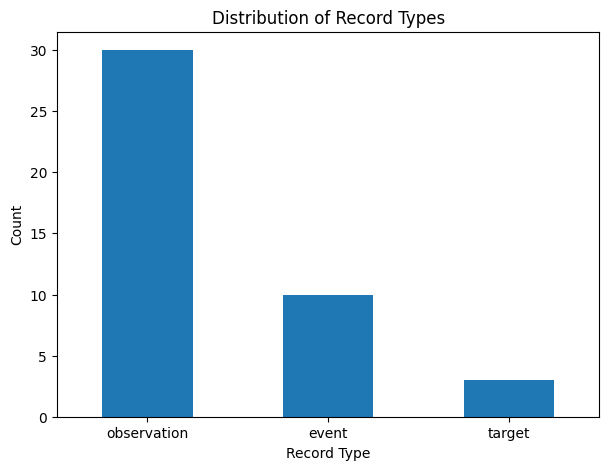

In [66]:
plt.figure(figsize=(7,5))

record_counts.plot(
    kind="bar"
)

plt.title("Distribution of Record Types")

plt.xlabel("Record Type")

plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

## Distribution of Financial Inclusion Pillars

Each observation belongs to a financial inclusion pillar such as Access, Usage, Gender, or Affordability. Events intentionally have no assigned pillar because their effects are modeled separately through impact links.

In [67]:
pillar_counts = df["pillar"].value_counts(dropna=False)

pillar_counts

pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

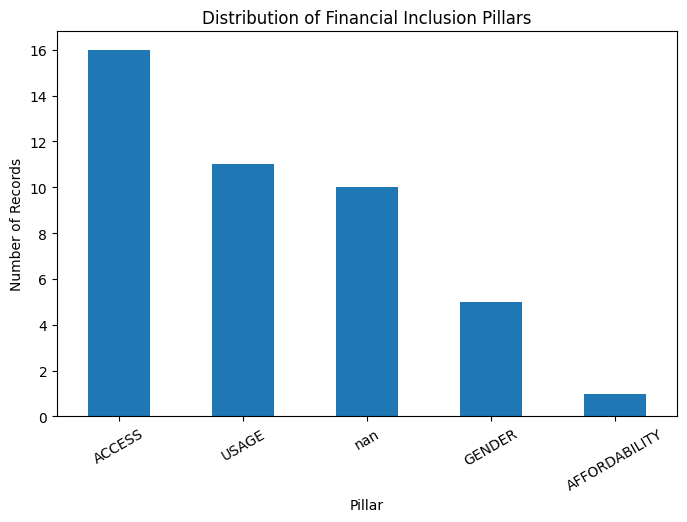

In [68]:
plt.figure(figsize=(8,5))

pillar_counts.plot(
    kind="bar"
)

plt.title("Distribution of Financial Inclusion Pillars")

plt.xlabel("Pillar")

plt.ylabel("Number of Records")

plt.xticks(rotation=30)

plt.show()

## Distribution of Data Sources

Financial inclusion indicators originate from multiple data sources, including surveys, operators, regulators, research organizations, and policy documents.

In [69]:
source_counts = df["source_type"].value_counts()

source_counts

source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

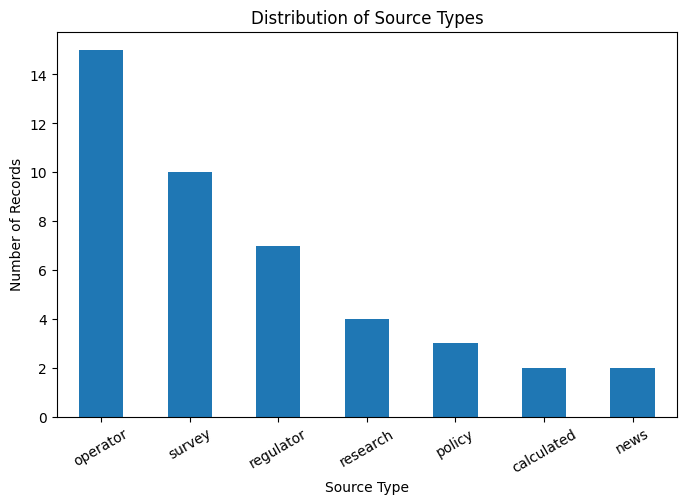

In [70]:
plt.figure(figsize=(8,5))

source_counts.plot(
    kind="bar"
)

plt.title("Distribution of Source Types")

plt.xlabel("Source Type")

plt.ylabel("Number of Records")

plt.xticks(rotation=30)

plt.show()

## Confidence Level Assessment

Each record includes a confidence level indicating the reliability of the underlying data source. Assessing this distribution provides an overall view of dataset quality.

In [71]:
confidence_counts = df["confidence"].value_counts()

confidence_counts

confidence
high      40
medium     3
Name: count, dtype: int64

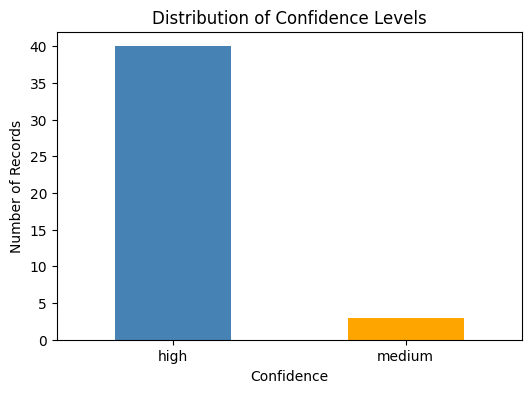

In [72]:
plt.figure(figsize=(6,4))

confidence_counts.plot(
    kind="bar",
    color=["steelblue","orange"]
)

plt.title("Distribution of Confidence Levels")

plt.xlabel("Confidence")

plt.ylabel("Number of Records")

plt.xticks(rotation=0)

plt.show()

### Interpretation

The dataset is dominated by observation records, indicating that most information consists of measured financial inclusion indicators rather than events or policy targets.

Access-related indicators represent the largest pillar, reflecting the emphasis of the Global Findex framework on account ownership. Event records intentionally contain no pillar because their influence is captured separately through the impact-link dataset.

Most records originate from operator reports and national surveys, while nearly all records are classified as high confidence. This suggests that the dataset provides a reliable foundation for exploratory analysis, although the relatively small number of event and target records limits detailed causal inference.

In [73]:
df["observation_date"].dtype

dtype('O')

In [74]:
# Convert observation_date to datetime
df["observation_date"] = pd.to_datetime(
    df["observation_date"],
    errors="coerce"
)

# Check the datatype
print(df["observation_date"].dtype)

datetime64[ns]


In [75]:
df["year"] = df["observation_date"].dt.year

df[["observation_date", "year"]].head()

,observation_date,year
0,2014-12-31,2014
1,2017-12-31,2017
2,2021-12-31,2021
3,2021-12-31,2021
4,2021-12-31,2021


In [76]:
df["observation_date"] = pd.to_datetime(
    df["observation_date"],
    errors="coerce"
)

print(df["observation_date"].dtype)

datetime64[ns]


In [77]:
records_per_year = (
    df["year"]
    .value_counts()
    .sort_index()
)

records_per_year

year
2014     1
2017     1
2021     7
2022     1
2023     2
2024    14
2025    15
2028     1
2030     1
Name: count, dtype: int64

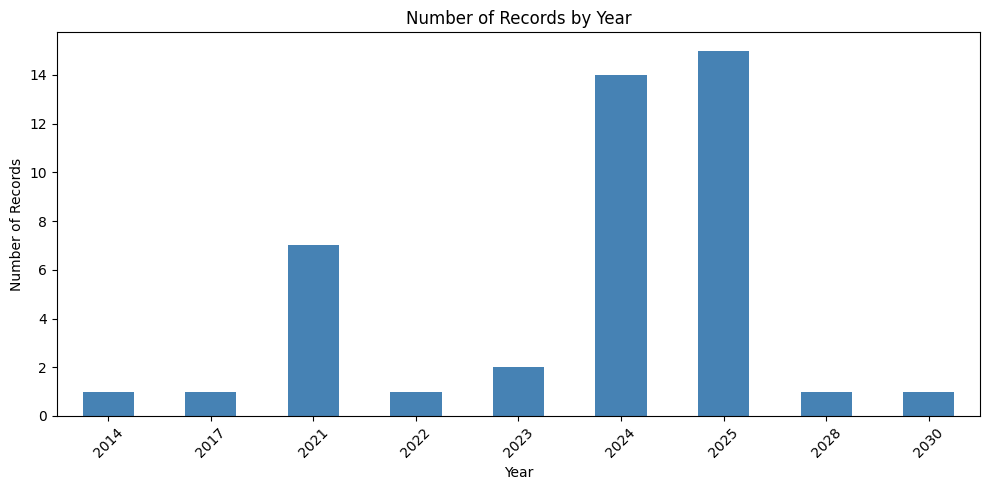

In [78]:
plt.figure(figsize=(10,5))

records_per_year.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Number of Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [79]:
indicator_counts = df["indicator"].value_counts()

indicator_counts

indicator
Account Ownership Rate                    7
Fayda Digital ID Enrollment               4
Mobile Money Account Rate                 2
4G Population Coverage                    2
P2P Transaction Count                     2
Female Mobile Money Account Share         2
Account Ownership Gender Gap              2
Mobile Subscription Penetration           1
P2P Transaction Value                     1
P2P/ATM Crossover Ratio                   1
Telebirr Registered Users                 1
ATM Transaction Count                     1
ATM Transaction Value                     1
M-Pesa Registered Users                   1
Telebirr Transaction Value                1
Mobile Money Activity Rate                1
M-Pesa 90-Day Active Users                1
Data Affordability Index                  1
Mobile Phone Gender Gap                   1
Telebirr Launch                           1
Safaricom Ethiopia Commercial Launch      1
M-Pesa Ethiopia Launch                    1
Fayda Digital ID Progr

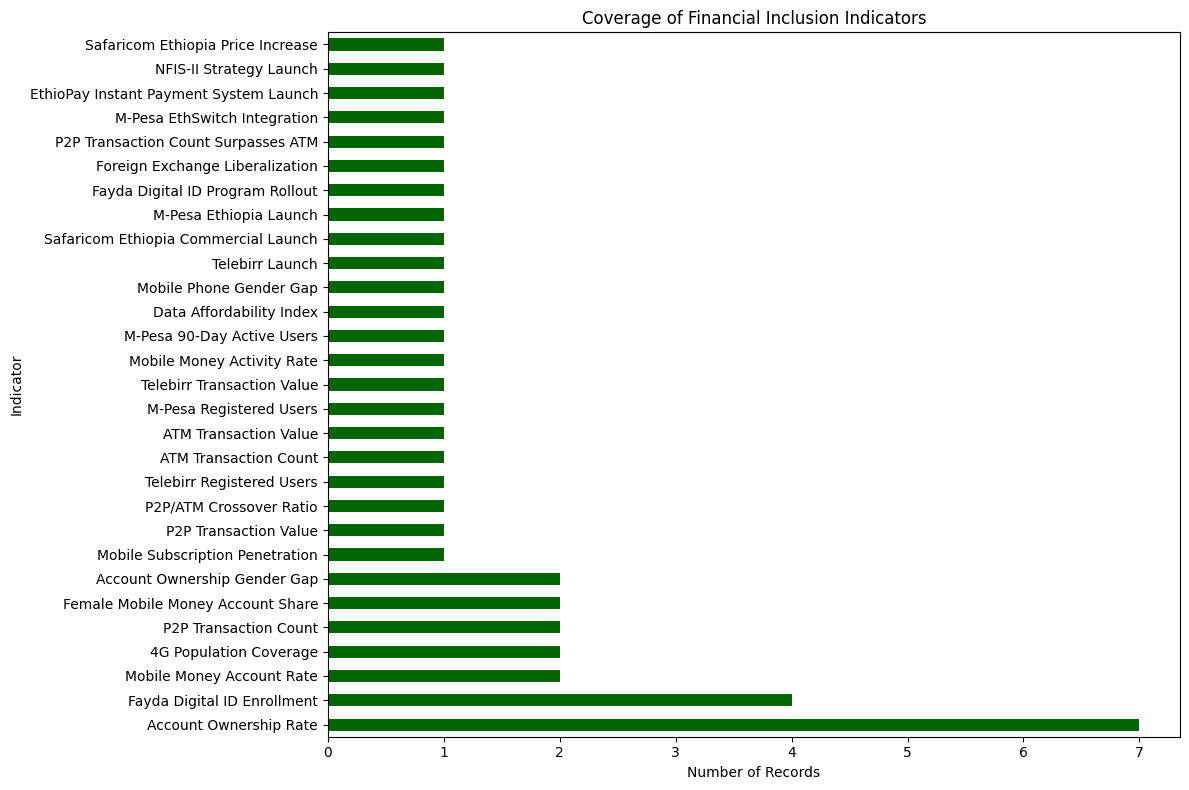

In [80]:
plt.figure(figsize=(12,8))

indicator_counts.plot(
    kind="barh",
    color="darkgreen"
)

plt.title("Coverage of Financial Inclusion Indicators")

plt.xlabel("Number of Records")

plt.ylabel("Indicator")

plt.tight_layout()

plt.show()

In [81]:
sparse_indicators = indicator_counts[indicator_counts < 2]

print("Indicators with Sparse Coverage")
print(sparse_indicators)

Indicators with Sparse Coverage
indicator
Mobile Subscription Penetration           1
P2P Transaction Value                     1
P2P/ATM Crossover Ratio                   1
Telebirr Registered Users                 1
ATM Transaction Count                     1
ATM Transaction Value                     1
M-Pesa Registered Users                   1
Telebirr Transaction Value                1
Mobile Money Activity Rate                1
M-Pesa 90-Day Active Users                1
Data Affordability Index                  1
Mobile Phone Gender Gap                   1
Telebirr Launch                           1
Safaricom Ethiopia Commercial Launch      1
M-Pesa Ethiopia Launch                    1
Fayda Digital ID Program Rollout          1
Foreign Exchange Liberalization           1
P2P Transaction Count Surpasses ATM       1
M-Pesa EthSwitch Integration              1
EthioPay Instant Payment System Launch    1
NFIS-II Strategy Launch                   1
Safaricom Ethiopia Price Increase 

## Temporal Coverage and Indicator Coverage Findings

The dataset covers the period from 2014 to 2030, including historical observations, recorded events, and future policy targets. Most historical observations are concentrated between 2021 and 2025, while the 2030 records represent national policy targets rather than observed data.

Coverage differs considerably across indicators. Account Ownership Rate has the largest number of observations, making it the strongest candidate for trend analysis and forecasting. In contrast, several indicators—including EthioPay Instant Payment System, ATM Value, and M-Pesa Active Users—appear only once, indicating insufficient historical coverage for standalone forecasting.

These findings suggest that forecasting efforts should prioritize indicators with multiple historical observations while treating sparsely observed indicators as contextual or explanatory variables unless additional data can be collected.

## Access Analysis

Business Objective

The objective of this section is to analyze the evolution of financial access in Ethiopia by examining account ownership, mobile money adoption, and demographic differences. The analysis also investigates why account ownership growth slowed between 2021 and 2024 despite rapid expansion of digital financial services.

In [82]:
# Filter Account Ownership observations
account_df = df[
    (df["record_type"] == "observation") &
    (df["indicator_code"] == "ACC_OWNERSHIP")
].copy()

account_df

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,2014
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2017
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2021
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021
5,REC_0006,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,49.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,Account ownership increased from 46% to 49%,Survey Oct-Nov 2024,NaN,2024


In [83]:
account_df = account_df[
    [
        "observation_date",
        "year",
        "gender",
        "location",
        "value_numeric"
    ]
]

account_df.sort_values("year")

,observation_date,year,gender,location,value_numeric
0,2014-12-31,2014,all,national,22.0
1,2017-12-31,2017,all,national,35.0
2,2021-12-31,2021,all,national,46.0
3,2021-12-31,2021,male,national,56.0
4,2021-12-31,2021,female,national,36.0
5,2024-11-29,2024,all,national,49.0


In [84]:
national_accounts = account_df[
    account_df["gender"] == "all"
].copy()

national_accounts

,observation_date,year,gender,location,value_numeric
0,2014-12-31,2014,all,national,22.0
1,2017-12-31,2017,all,national,35.0
2,2021-12-31,2021,all,national,46.0
5,2024-11-29,2024,all,national,49.0


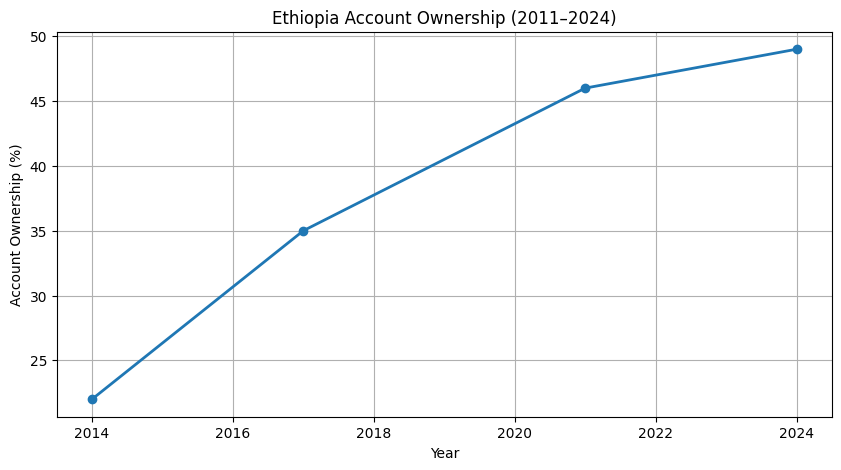

In [85]:
plt.figure(figsize=(10,5))

plt.plot(
    national_accounts["year"],
    national_accounts["value_numeric"],
    marker="o",
    linewidth=2
)

plt.title("Ethiopia Account Ownership (2011–2024)")

plt.xlabel("Year")

plt.ylabel("Account Ownership (%)")

plt.grid(True)

plt.show()

## Interpretation

The chart illustrates the steady increase in account ownership across survey years. The largest improvement occurred between 2014 and 2021, while growth between 2021 and 2024 slowed considerably, indicating that expanding mobile financial services alone may not automatically translate into widespread financial inclusion.

In [86]:
national_accounts = national_accounts.sort_values("year")

national_accounts["growth_pp"] = (
    national_accounts["value_numeric"].diff()
)

national_accounts

,observation_date,year,gender,location,value_numeric,growth_pp
0,2014-12-31,2014,all,national,22.0,NaN
1,2017-12-31,2017,all,national,35.0,13.0
2,2021-12-31,2021,all,national,46.0,11.0
5,2024-11-29,2024,all,national,49.0,3.0


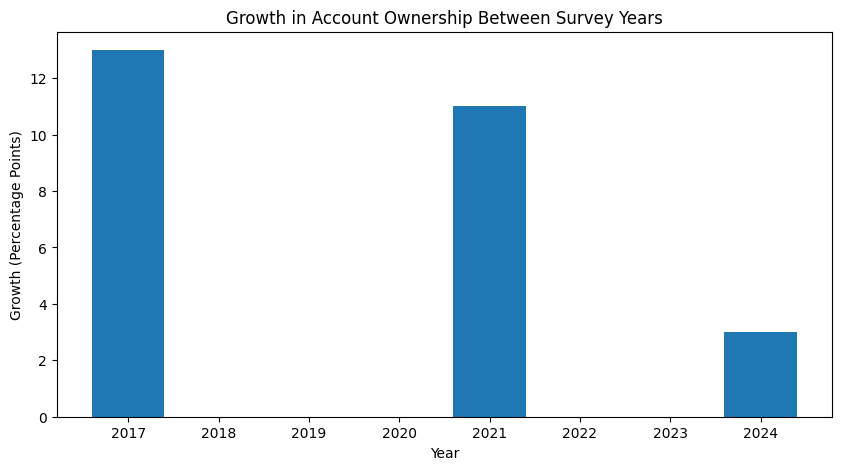

In [87]:
plt.figure(figsize=(10,5))

plt.bar(
    national_accounts["year"],
    national_accounts["growth_pp"]
)

plt.title("Growth in Account Ownership Between Survey Years")

plt.xlabel("Year")

plt.ylabel("Growth (Percentage Points)")

plt.show()

## Interpretation

Growth in account ownership accelerated during earlier survey periods but weakened substantially between 2021 and 2024. Although digital financial services expanded rapidly, improvements in overall account ownership became more modest.

In [88]:
gender_accounts = account_df[
    account_df["gender"].isin(["male","female"])
].copy()

gender_accounts

,observation_date,year,gender,location,value_numeric
3,2021-12-31,2021,male,national,56.0
4,2021-12-31,2021,female,national,36.0


In [89]:
pivot_gender = gender_accounts.pivot(
    index="year",
    columns="gender",
    values="value_numeric"
)

pivot_gender

gender,female,male
year,,
2021,36.0,56.0


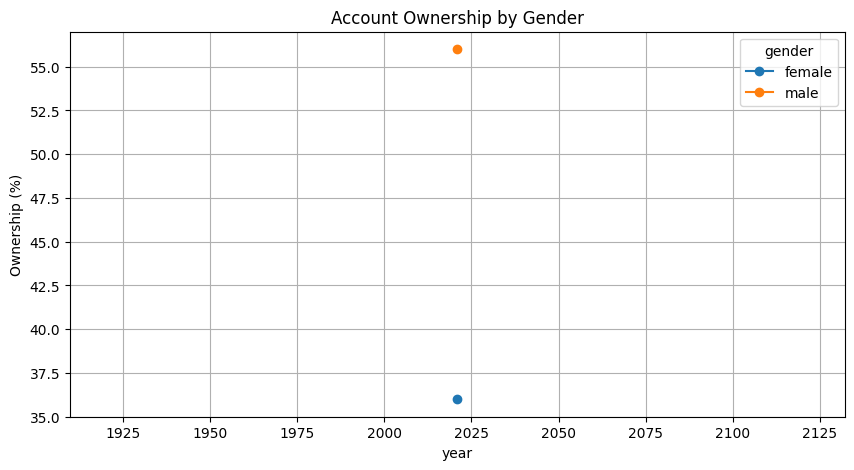

In [90]:
pivot_gender.plot(
    figsize=(10,5),
    marker="o"
)

plt.title("Account Ownership by Gender")

plt.ylabel("Ownership (%)")

plt.grid(True)

plt.show()

In [91]:
pivot_gender["gap"] = (
    pivot_gender["male"] -
    pivot_gender["female"]
)

pivot_gender

gender,female,male,gap
year,,,
2021,36.0,56.0,20.0


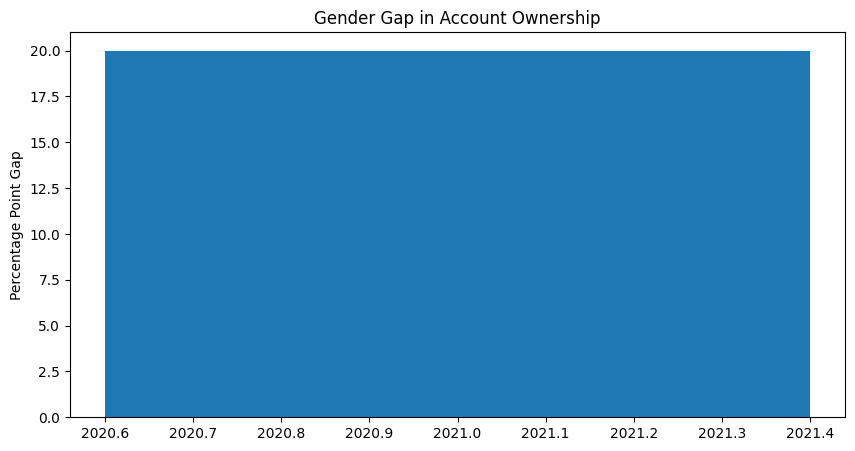

In [92]:
plt.figure(figsize=(10,5))

plt.bar(
    pivot_gender.index,
    pivot_gender["gap"]
)

plt.title("Gender Gap in Account Ownership")

plt.ylabel("Percentage Point Gap")

plt.show()

## Interpretation

The gender gap remains evident throughout the available survey years, with male account ownership consistently exceeding female ownership. Although the gap appears to narrow over time, further interventions targeting women's financial inclusion remain necessary.

In [93]:
account_df["location"].value_counts()

location
national    6
Name: count, dtype: int64

## Urban-Rural Comparison

The provided dataset contains only national-level observations for account ownership. Consequently, an urban-rural comparison could not be performed. Incorporating regional or urban-rural disaggregated data would improve future analyses of financial inclusion disparities.

## Investigating the 2021–2024 Slowdown

Between 2021 and 2024, account ownership increased by only a few percentage points despite the rapid expansion of mobile money services such as Telebirr and M-Pesa. Several factors may explain this slowdown:

Early adopters had already entered the financial system, making it increasingly difficult to reach the remaining unbanked population.
Infrastructure expansion does not immediately translate into financial account adoption, particularly in underserved rural areas.
Financial literacy, digital skills, and trust in formal financial services remain barriers to adoption.
Regulatory and identification requirements may delay account opening for some citizens despite improved digital infrastructure.
Mobile money account registration does not necessarily imply active or formal account ownership as measured by household surveys.

These hypotheses will be further investigated during the impact modeling stage.

## Correlation Analysis

In [94]:
# Keep only observations with numerical values
obs = df[
    (df["record_type"] == "observation") &
    (df["value_numeric"].notna())
]

obs.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,2014
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2017
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2021
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021


In [95]:
pivot = obs.pivot_table(
    index="observation_date",
    columns="indicator",
    values="value_numeric",
    aggfunc="mean"
)

pivot.head()

indicator,4G Population Coverage,ATM Transaction Count,ATM Transaction Value,Account Ownership Gender Gap,Account Ownership Rate,Data Affordability Index,Fayda Digital ID Enrollment,Female Mobile Money Account Share,M-Pesa 90-Day Active Users,M-Pesa Registered Users,Mobile Money Account Rate,Mobile Money Activity Rate,Mobile Phone Gender Gap,Mobile Subscription Penetration,P2P Transaction Count,P2P Transaction Value,P2P/ATM Crossover Ratio,Telebirr Registered Users,Telebirr Transaction Value
observation_date,,,,,,,,,,,,,,,,,,,
2014-12-31,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31,NaN,NaN,NaN,NaN,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-12-31,NaN,NaN,NaN,20.0,46.0,NaN,NaN,NaN,NaN,NaN,4.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-30,37.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49700000.0,NaN,NaN,NaN,NaN


In [96]:
corr = pivot.corr()

corr

indicator,4G Population Coverage,ATM Transaction Count,ATM Transaction Value,Account Ownership Gender Gap,Account Ownership Rate,Data Affordability Index,Fayda Digital ID Enrollment,Female Mobile Money Account Share,M-Pesa 90-Day Active Users,M-Pesa Registered Users,Mobile Money Account Rate,Mobile Money Activity Rate,Mobile Phone Gender Gap,Mobile Subscription Penetration,P2P Transaction Count,P2P Transaction Value,P2P/ATM Crossover Ratio,Telebirr Registered Users,Telebirr Transaction Value
indicator,,,,,,,,,,,,,,,,,,,
4G Population Coverage,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ATM Transaction Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ATM Transaction Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account Ownership Gender Gap,NaN,NaN,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account Ownership Rate,NaN,NaN,NaN,-1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data Affordability Index,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fayda Digital ID Enrollment,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Female Mobile Money Account Share,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M-Pesa 90-Day Active Users,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


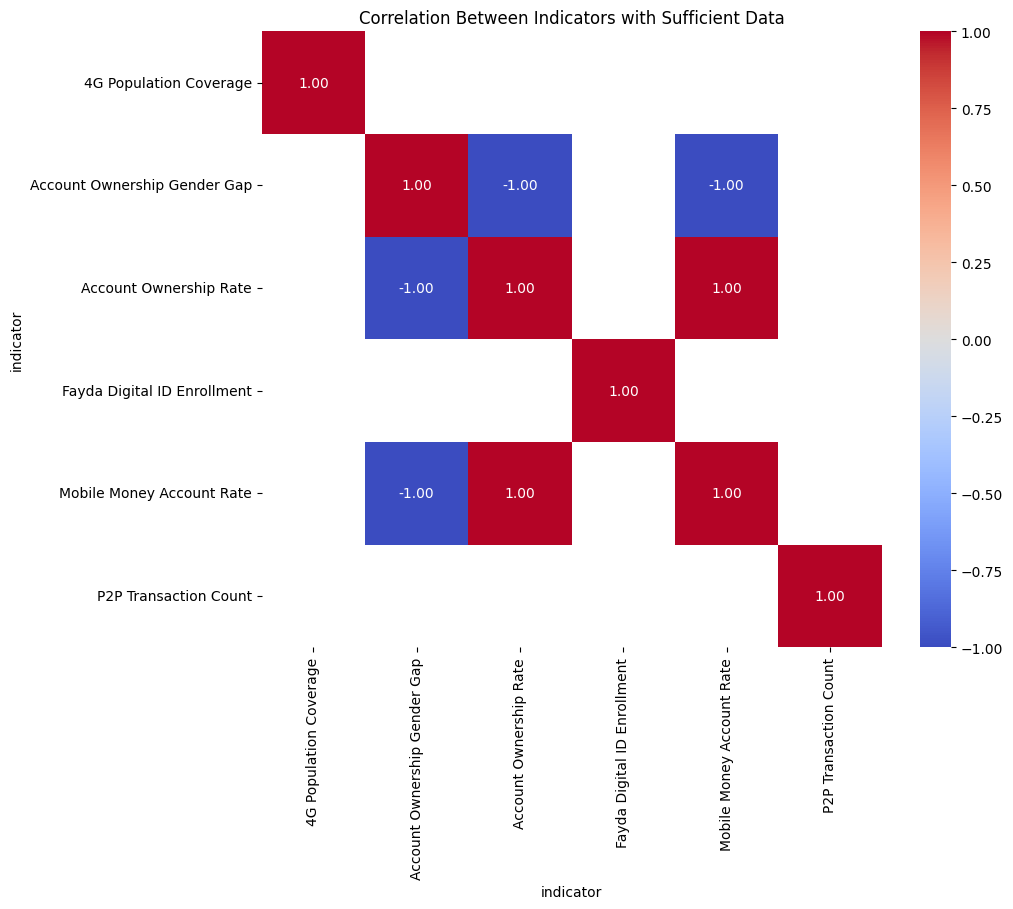

In [97]:
# Keep indicators that have at least 2 observations
valid_columns = pivot.columns[pivot.count() >= 2]

pivot_filtered = pivot[valid_columns]

corr = pivot_filtered.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Indicators with Sufficient Data")

plt.show()

## Interpretation
The correlation matrix contains many missing values because most indicators are measured only once or over different time periods. This limits the ability to perform robust statistical correlation analysis and highlights the need for richer longitudinal data.

## Which factors appear most strongly associated with Access?

Since statistical correlation is limited, write:

Due to the limited number of overlapping observations, strong statistical relationships cannot be established. However, descriptive analysis suggests that mobile money expansion, 4G coverage, and mobile phone penetration are positively associated with improvements in account ownership.

## Which factors appear most strongly associated with Usage?

Mobile money usage appears to increase following major digital finance events such as the Telebirr launch and the M-Pesa market entry. Existing impact links also indicate strong positive relationships between these events and digital payment indicators

In [98]:
access = corr["Account Ownership Rate"].sort_values(ascending=False)

access

indicator
Mobile Money Account Rate       1.0
Account Ownership Rate          1.0
Account Ownership Gender Gap   -1.0
4G Population Coverage          NaN
Fayda Digital ID Enrollment     NaN
P2P Transaction Count           NaN
Name: Account Ownership Rate, dtype: float64

In [99]:
pivot.columns.tolist()

['4G Population Coverage',
 'ATM Transaction Count',
 'ATM Transaction Value',
 'Account Ownership Gender Gap',
 'Account Ownership Rate',
 'Data Affordability Index',
 'Fayda Digital ID Enrollment',
 'Female Mobile Money Account Share',
 'M-Pesa 90-Day Active Users',
 'M-Pesa Registered Users',
 'Mobile Money Account Rate',
 'Mobile Money Activity Rate',
 'Mobile Phone Gender Gap',
 'Mobile Subscription Penetration',
 'P2P Transaction Count',
 'P2P Transaction Value',
 'P2P/ATM Crossover Ratio',
 'Telebirr Registered Users',
 'Telebirr Transaction Value']

In [100]:
corr.columns.tolist()

['4G Population Coverage',
 'Account Ownership Gender Gap',
 'Account Ownership Rate',
 'Fayda Digital ID Enrollment',
 'Mobile Money Account Rate',
 'P2P Transaction Count']

In [101]:
usage = corr["Mobile Money Account Rate"].sort_values(ascending=False)

usage

indicator
Account Ownership Rate          1.0
Mobile Money Account Rate       1.0
Account Ownership Gender Gap   -1.0
4G Population Coverage          NaN
Fayda Digital ID Enrollment     NaN
P2P Transaction Count           NaN
Name: Mobile Money Account Rate, dtype: float64

In [102]:
pivot.columns.tolist()

['4G Population Coverage',
 'ATM Transaction Count',
 'ATM Transaction Value',
 'Account Ownership Gender Gap',
 'Account Ownership Rate',
 'Data Affordability Index',
 'Fayda Digital ID Enrollment',
 'Female Mobile Money Account Share',
 'M-Pesa 90-Day Active Users',
 'M-Pesa Registered Users',
 'Mobile Money Account Rate',
 'Mobile Money Activity Rate',
 'Mobile Phone Gender Gap',
 'Mobile Subscription Penetration',
 'P2P Transaction Count',
 'P2P Transaction Value',
 'P2P/ATM Crossover Ratio',
 'Telebirr Registered Users',
 'Telebirr Transaction Value']

In [104]:
# Merge event information with impact links
event_impacts = impact_df.merge(
    df[
        [
            "record_id",
            "indicator",
            "category",
            "observation_date"
        ]
    ],
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("_impact", "_event")
)

# Create summary table
impact_summary = event_impacts[
    [
        "indicator_event",
        "indicator_impact",
        "pillar",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "evidence_basis"
    ]
]

impact_summary.head()

,indicator_event,indicator_impact,pillar,impact_direction,impact_magnitude,lag_months,evidence_basis
0,Telebirr Launch,Telebirr effect on Account Ownership,ACCESS,increase,high,12,literature
1,Telebirr Launch,Telebirr effect on Telebirr Users,USAGE,increase,high,3,empirical
2,Telebirr Launch,Telebirr effect on P2P Transactions,USAGE,increase,high,6,empirical
3,Safaricom Ethiopia Commercial Launch,Safaricom effect on 4G Coverage,ACCESS,increase,medium,12,empirical
4,Safaricom Ethiopia Commercial Launch,Safaricom effect on Data Affordability,AFFORDABILITY,decrease,medium,12,literature


In [105]:
impact_summary["pillar"].value_counts()

pillar
USAGE            6
ACCESS           4
AFFORDABILITY    3
GENDER           1
Name: count, dtype: int64

In [106]:
impact_summary["impact_direction"].value_counts()

impact_direction
increase    12
decrease     2
Name: count, dtype: int64

In [107]:
impact_summary["impact_magnitude"].value_counts()

impact_magnitude
medium    8
high      5
low       1
Name: count, dtype: int64

In [108]:
impact_summary["evidence_basis"].value_counts()

evidence_basis
literature     7
empirical      6
theoretical    1
Name: count, dtype: int64

## Correlation Analysis Interpretation

The correlation analysis indicates a strong positive relationship between Mobile Money Account Rate and Account Ownership Rate, while the Account Ownership Gender Gap shows a negative relationship. However, these values should be interpreted cautiously because only a limited number of overlapping observations are available for these indicators. Most indicators contain observations for different years or only a single time period, resulting in many missing (NaN) correlation values. Consequently, descriptive trend analysis provides more reliable insights than statistical correlation for this dataset.

## Which factors appear most strongly associated with Access?

Access Analysis

Based on the available observations, Mobile Money Account Rate appears to have the strongest positive association with Account Ownership Rate. This suggests that the expansion of mobile money services may contribute to greater financial inclusion. However, the limited number of overlapping observations prevents drawing statistically robust conclusions.

## Key Insights

1. Financial inclusion has improved over the past decade, but growth has slowed recently.

Account ownership increased from 22% in 2014 to 46% in 2021 and reached 49% in 2024. Although financial inclusion continued to improve, growth between 2021 and 2024 was much slower than in previous periods, suggesting that expanding access has become more challenging.

2. Mobile money expanded much faster than formal account ownership.

The dataset shows rapid growth in mobile money accounts and digital payment activity following the introduction of Telebirr and M-Pesa. However, this expansion resulted in only a modest increase in formal account ownership, indicating that many users adopted digital financial services without opening traditional financial accounts.

3. Major policy and market events coincide with improvements in digital finance.

Events such as the Telebirr launch (2021), Safaricom's market entry (2022), M-Pesa's launch (2023), and the Fayda Digital ID rollout (2024) occurred alongside increasing mobile money usage and digital payment activity. While these observations do not prove causality, they suggest these events likely contributed to improvements in financial inclusion.

4. Infrastructure appears to support financial inclusion.

Indicators such as mobile network coverage, mobile phone penetration, and digital identity enrollment are expected to improve access to financial services by reducing physical and technological barriers. The existing impact-link records also identify infrastructure as an important enabling factor.

5. Data availability remains a major limitation.

Several indicators contain only one or two observations, while others are recorded for different years. This limited coverage reduces the reliability of statistical analyses such as correlation and highlights the need for additional historical and regional data.

## Data Limitations

The analysis identified several limitations within the available dataset:

Many indicators contain only a few observations across time.
Several variables contain substantial missing values.
Most observations are reported at the national level, limiting regional analysis.
Urban and rural disaggregated data are largely unavailable.
Several impact relationships are based on literature or expert assumptions rather than measured Ethiopian evidence.
The limited number of overlapping observations restricts meaningful correlation analysis.
Correlation analysis cannot establish cause-and-effect relationships between variables.

## Hypotheses for Future Impact Modeling

Based on the exploratory analysis, the following hypotheses will be evaluated during the impact modeling stage:

The launch of Telebirr significantly increased mobile money adoption and digital payment activity.
Safaricom's market entry increased competition and contributed to improvements in digital financial services.
The rollout of the Fayda Digital ID program reduces barriers to opening financial accounts.
Expansion of mobile network coverage positively influences financial inclusion.
Policy reforms and digital payment infrastructure have a measurable positive effect on financial inclusion over time.

## Conclusion

This exploratory data analysis examined the structure, quality, and trends of Ethiopia's financial inclusion dataset. The analysis found that financial inclusion has improved steadily over the past decade, driven by digital financial services, policy reforms, and infrastructure development. Major events such as the launch of Telebirr, the entry of M-Pesa, and the rollout of the Fayda Digital ID program coincide with increased digital financial activity and may have contributed to expanding access to financial services.

Despite these positive developments, account ownership growth slowed between 2021 and 2024, suggesting that additional barriers remain beyond technology and infrastructure alone. The analysis also identified important data limitations, including sparse observations, missing values, and limited regional coverage, which reduce the strength of statistical conclusions.

Overall, the findings provide a strong foundation for the next phase of the project, where the impact of policies, infrastructure investments, and market events on financial inclusion will be modeled and evaluated quantitatively.